In [ ]:
from tree_search import *
%load_ext autoreload
%autoreload 2

In [ ]:
data_folder = "../../monkey_4iar/analysis/data/processed/harry/models/2023-02"
fold_idx = 0
index = 0

train_data = pd.read_csv(f"{data_folder}/split_{fold_idx}.csv")
trial = train_data.iloc[index]

In [ ]:
black_, white_, move_= trial.black, trial.white, trial.move
board = fourbynine_board(fourbynine_pattern(int(black_)), fourbynine_pattern(int(white_)))
actual_move = int(move_).bit_length() - 1

In [ ]:
from graphviz import Digraph
import numpy as np

def tree_to_graphviz(root, max_depth=None):
    dot = Digraph(comment="Search Tree")

    # Set default node attrs ONCE
    dot.attr(
        "node",
        shape="box",
        fontname="Courier New",   # or "Courier New" / "monospace"
        margin="0.2,0.2",     # x,y padding inside the box
    )

    visited = {}
    counter = [0]

    def add_node_rec(node, depth):
        if max_depth is not None and depth > max_depth:
            return None

        if node not in visited:
            node_id = f"n{counter[0]}"
            counter[0] += 1
            visited[node] = node_id

            raw = node.get_board().to_string()
            # normalize newlines just in case
            raw = raw.replace("\r\n", "\n")

            board_str = (
                raw.replace("o", "●")
                   .replace("x", "○")
                   .replace(" ", "·")
                   .replace("|", "")
                   .replace("-", "")
                   .replace("+", "")
                   .replace("\n", r"\l")  # literal "\l" for Graphviz
            )

            value = node.get_value()
            label = f"{board_str}\\lValue: {np.round(value, 2)}\\l"

            dot.node(node_id, label=label)
        else:
            node_id = visited[node]

        for child in node.get_children():
            if max_depth is not None and depth >= max_depth:
                continue
            child_id = add_node_rec(child, depth + 1)
            if child_id is not None:
                dot.edge(node_id, child_id, fontname="Courier")

        return node_id

    add_node_rec(root, depth=0)
    return dot


Parameter names: ['pruning_threshold', 'stopping_prob', 'feature_drop', 'lapse_rate', 'opp_scale', 'center_weight', '1IAR', '2IAR_CON', '2IAR_DIS', '3IAR_CON', '3IAR_DIS', '4IAR']


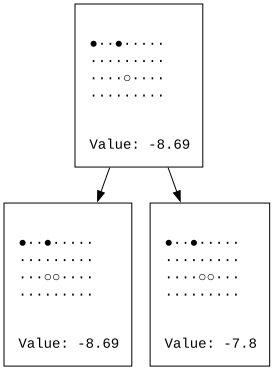

In [ ]:
self = TreeSearch()
self.set_params(self.initial_params)
heuristic = self.heuristic
search = fourbynine.NInARowBestFirstSearch(heuristic, board)



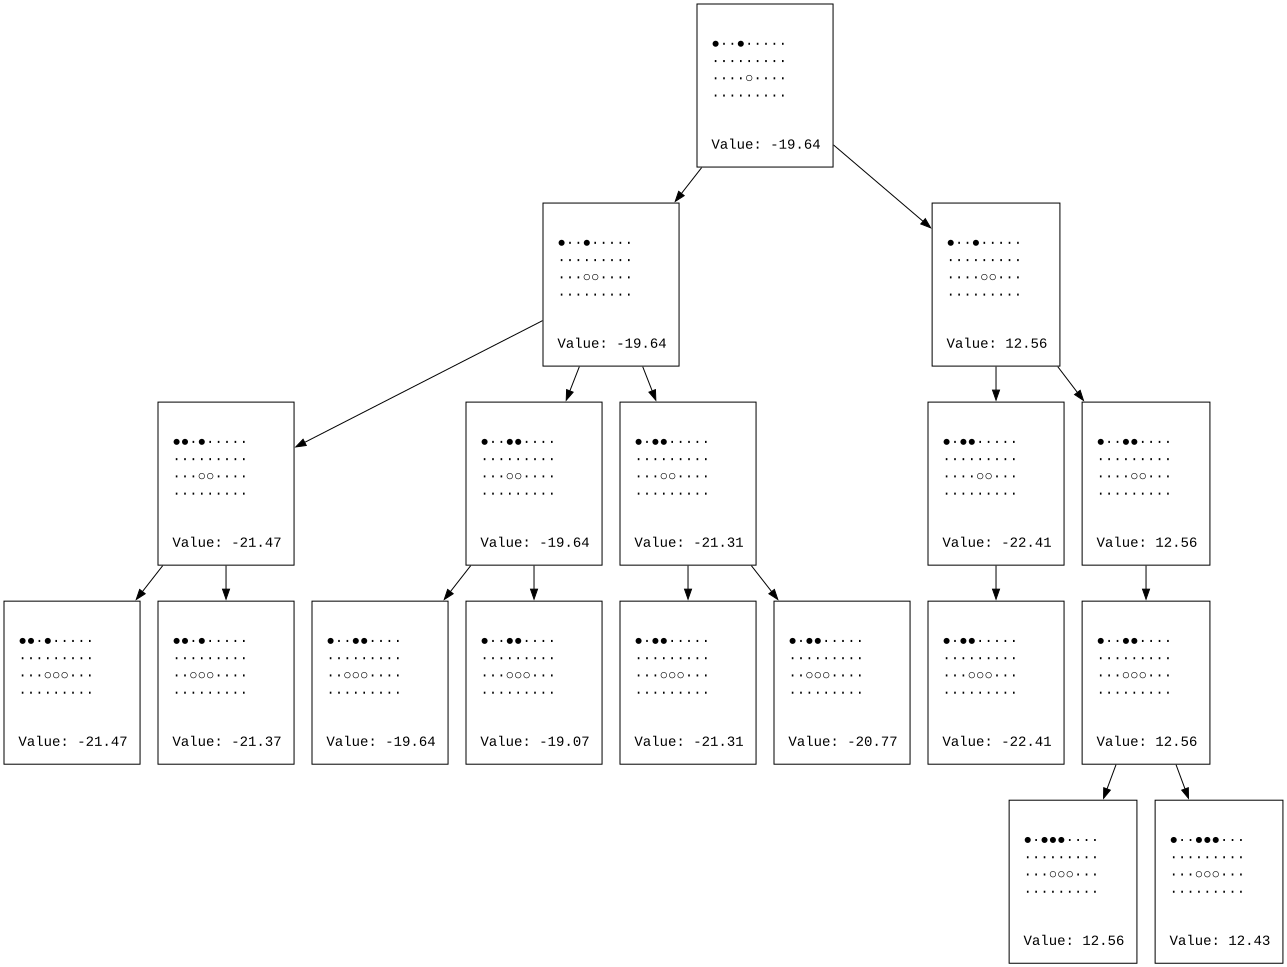

In [ ]:
while not search.advance_search():
    break

root = search.get_tree()
tree_to_graphviz(root)